--- Анализ файла: data_idxs_for_debug.npy ---
Форма массива (количество строк/признаков): (14, 10018)

# Статистика для Строки 0:
  Min: 47.0000
  Max: 65.0000
  Mean: 56.0393
  Std Dev: 5.3212

# Статистика для Строки 1:
  Min: 47.0000
  Max: 83.0000
  Mean: 65.6004
  Std Dev: 11.5125

# Статистика для Строки 2:
  Min: 15.0000
  Max: 758.0000
  Mean: 389.6707
  Std Dev: 213.4168

# Статистика для Строки 3:
  Min: 0.0863
  Max: 1.0877
  Mean: 0.5832
  Std Dev: 0.2906

# Статистика для Строки 4:
  Min: 0.0833
  Max: 1.0000
  Mean: 0.5385
  Std Dev: 0.2886

# Статистика для Строки 5:
  Min: 0.3427
  Max: 0.5670
  Mean: 0.4553
  Std Dev: 0.0663

# Статистика для Строки 6:
  Min: 0.0000
  Max: 0.2250
  Mean: 0.1163
  Std Dev: 0.0720

============--- ТАРГЕТЫ 'y' НАЧИНАЮТСЯ ЗДЕСЬ ---============

# Статистика для Строки 7:
  Min: 0.9774
  Max: 32.0352
  Mean: 11.5736
  Std Dev: 4.9048

# Статистика для Строки 8:
  Min: 0.9774
  Max: 25.0275
  Mean: 7.9739
  Std Dev: 3.4308

# Статистика для 

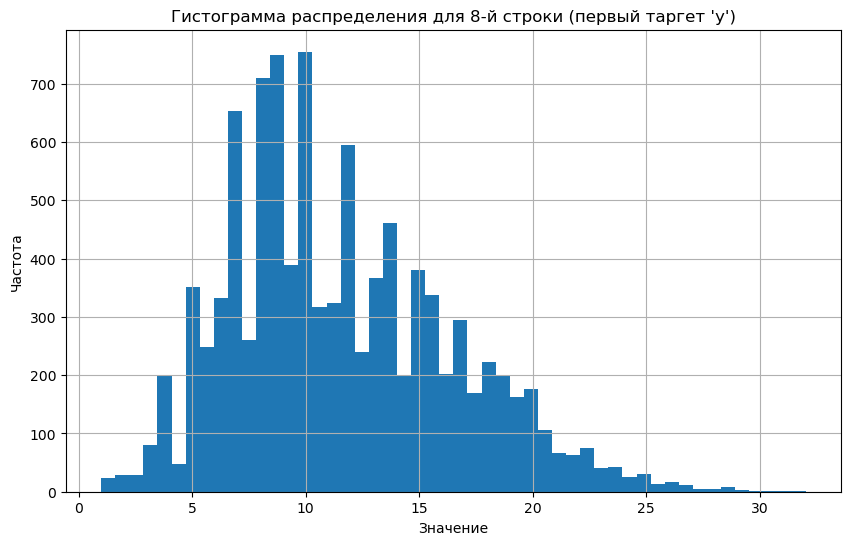

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# --- Настройки ---
# Убедись, что путь к файлу правильный
file_path = 'data_idxs_for_debug.npy' 
# -----------------

# Включаем отображение графиков прямо в ноутбуке
%matplotlib inline

try:
    # Загружаем массив из файла
    data_column = np.load(file_path)
    
    print(f"--- Анализ файла: {file_path} ---")
    print(f"Форма массива (количество строк/признаков): {data_column.shape}")
    print("="*60)

    # Проходимся по каждой строке массива
    for i in range(data_column.shape[0]):
        row_data = data_column[i]
        
        # Ставим разделитель перед 8-й строкой (индекс 7), где начинаются таргеты 'y'
        if i == 7:
            print("\n" + "--- ТАРГЕТЫ 'y' НАЧИНАЮТСЯ ЗДЕСЬ ---".center(60, "="))

        # Считаем и выводим статистику для текущей строки
        print(f"\n# Статистика для Строки {i}:")
        print(f"  Min: {np.min(row_data):.4f}")
        print(f"  Max: {np.max(row_data):.4f}")
        print(f"  Mean: {np.mean(row_data):.4f}")
        print(f"  Std Dev: {np.std(row_data):.4f}")

    # Визуализируем распределение для первой таргетной переменной (8-я строка)
    if data_column.shape[0] > 7:
        plt.figure(figsize=(10, 6))
        plt.hist(data_column[7], bins=50)
        plt.title("Гистограмма распределения для 8-й строки (первый таргет 'y')")
        plt.xlabel("Значение")
        plt.ylabel("Частота")
        plt.grid(True)
        plt.show()

except FileNotFoundError:
    print(f"Ошибка: Файл '{file_path}' не найден. Проверь путь и имя файла.")
except Exception as e:
    print(f"Произошла ошибка: {e}")

In [5]:
data_column

array([[ 54.       ,  54.       ,  54.       , ...,  52.       ,
         52.       ,  52.       ],
       [ 65.       ,  65.       ,  65.       , ...,  65.       ,
         65.       ,  65.       ],
       [ 15.       ,  29.       ,  43.       , ..., 729.       ,
        743.       , 757.       ],
       ...,
       [  4.256991 ,   4.990068 ,   4.012632 , ...,   2.623644 ,
          2.739393 ,   3.21525  ],
       [  3.34386  ,   4.012632 ,   4.012632 , ...,   2.623644 ,
          2.623644 ,   2.623644 ],
       [  2.006316 ,   2.4461622,   2.4461622, ...,   1.491876 ,
          2.0011716,   2.623644 ]])

In [7]:
import pandas as pd

path = "data/cmip5_world/target.parquet"

# Load (requires either 'pyarrow' or 'fastparquet')
df = pd.read_parquet(path, engine="fastparquet")  # or engine="fastparquet"

# Optional: better display in notebooks
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 0)

# Quick look
print("Shape:", df.shape)
display(df.head(10))  # if not in a notebook, use: print(df.head(10))
print("\nDtypes:\n", df.dtypes)

Shape: (15930329, 6)


,time,station_name,y,lat,lon,height
0,2006-02-02,тегюлтя,1.0,59.99952,0.0,173.0
1,2006-02-02,тегюлтя,4.0,59.99952,0.0,173.0
2,2006-02-02,тегюлтя,4.0,59.99952,0.0,173.0
3,2006-02-02,тегюлтя,4.0,59.99952,0.0,173.0
4,2006-02-02,тегюлтя,4.0,59.99952,0.0,173.0
5,2006-02-02,тегюлтя,3.0,59.99952,0.0,173.0
6,2006-02-02,тегюлтя,4.0,59.99952,0.0,173.0
7,2006-02-02,тегюлтя,4.0,59.99952,0.0,173.0
8,2006-02-03,тегюлтя,5.0,59.99952,0.0,173.0
9,2006-02-03,тегюлтя,4.0,59.99952,0.0,173.0



Dtypes:
 time            datetime64[ns]
station_name            object
y                      float64
lat                    float64
lon                    float64
height                 float64
dtype: object


In [8]:
df[df['y']>30]

,time,station_name,y,lat,lon,height
70324,2006-02-27,терней,32.000000,45.42028,0.00,51.0
70325,2006-02-27,терней,31.000000,45.42028,0.00,51.0
72469,2006-11-22,терней,33.000000,45.42028,0.00,51.0
72470,2006-11-22,терней,34.000000,45.42028,0.00,51.0
72472,2006-11-22,терней,39.000000,45.42028,0.00,51.0
...,...,...,...,...,...,...
15915713,2009-06-25,88963099999,33.387156,-63.36393,146.25,NaN
15915714,2009-06-26,88963099999,30.763512,-63.36393,146.25,NaN
15915724,2009-07-06,88963099999,30.763512,-63.36393,146.25,NaN
15915781,2009-09-01,88963099999,30.763512,-63.36393,146.25,NaN
